# Simple 2D Random Walks

In this notebook, we want to expand our random walker's space from one dimension (left-right only) to two dimensions. Our random walker will be able to wander all over the 2D plane. What freedom!!


To accomplish this feat, we will have to revamp a few ideas/functions from the 1D random walk:

> 1. How we do make a **random move in two dimensions**?

> 2. How we do code the random walk with both **x and y components**?

## Random moves in Two Dimensions:

**Unlike 1D, there are many different ways to move in 2D**

Two common ways include:

> **On a "grid"**: up, down, left, right (i.e. Cartesian coordinates)

> **On a "unit" circle**: use any angle $\theta$ between 0 and $2\pi$ radians (i.e. polar coordinates)


<img src="./unit-circle.png" width="300" align="left">

**Let's try writing a function for each method above**

In the two cells below , you must complete the function for:

>  1. **rand_grid**: function for grid-type move

>  2. **rand_angle**: function for random angle-type move


Remember, for each function you are returning two values for a 2D "step":

>     a move in the x direction (xdelta)
>     a move in the y direction (ydelta)

**Note: Solution to this exercise is given in  randomwalk2d solutions notebook if you get stuck.**

Don't give up too soon.

In [ ]:
#  **Execute this cell to import libraries used in exercises**

import numpy as np
import random as random

## Exercise 1: rand_grid function

In [ ]:
def rand_grid():
    #Generates xdelta and ydelta, i.e. how far we move along each axis for a single step
    #This function should generate a random step on a rectangular grid (i.e. the familiar X-Y plane)

    ########################
    #   YOUR CODE GOES HERE
    #######################

    steps = [-1, 0, 1]
    xdelta = random.choice(steps)
    ydelta = random.choice(steps)

    return xdelta, ydelta

xstep, ystep = rand_grid()
print(xstep, ystep)

-1 1


## Exercise 2: rand_angle function

In [ ]:
def rand_angle():
    #Generates xdelta and ydelta, i.e. how far we move along each axis for a single step
    #This function should generate a random step in an arbitrary direction (i.e. some angle 0 <= theta < 2*Pi)
    #########################
    #   YOUR CODE GOES HERE
    #########################

    theta = random.uniform(0, 2 * np.pi)

    xdelta = np.cos(theta)
    ydelta = np.sin(theta)

    return xdelta, ydelta

xstep, ystep = rand_angle()
print(xstep, ystep)

0.5438416847326477 -0.8391878347230466


## With our  random move functions, we can create a 2D random walk function

We will opt to use the **rand_angle** function for movement in 2D, since it seems most natural for a molecule...molecules don't move on **grids** in a cell.

Some starting values are given for you. **xwalk, ywalk** are lists of the walker's x and y position for each step, the function will return **xwalk, ywalk**:

```
    xwalk = [0]    # x-direction sequence starting at 0
    ywalk = [0]    # y-direction sequence starting at 0
    x, y  = 0, 0   # Variable for current x and y position of walker  

```

**Note: Solution to this exercise is given in randomwalk2d solutions notebook if you get stuck.**

Don't give up too soon.









## Exercise 3: random_walk2d function

In [ ]:
def random_walk2d(steps):
    """
    Performs 2D random walk with number of steps = steps
    At each step, walker moves on the unit circle
    """
    xwalk = np.zeros(steps+1)    # x-direction sequence starting at 0
    ywalk = np.zeros(steps+1)    # y-direction sequence starting at 0
    x, y  = 0, 0                 # Variable for current x and y position of walker

###########################################################################
#    Add your code HERE to complete this function.
#    Perform random walk in each axis (xwalk, ywalk) using rand_angle
#          to get lengths of each step.
#    HINT: Use for loop over the number of steps (steps). Change xwalk and
#      ywalk values based on step lengths (xdelta, ydelta) from rand_angle
#    Returns xwalk, ywalk arrays
###########################################################################

    for i in range(1, steps + 1):
        xdelta, ydelta = rand_angle()

        x += xdelta
        y += ydelta

        xwalk[i] = x
        ywalk[i] = y

    return xwalk, ywalk


xwalk1, ywalk1 = random_walk2d(10)
print(xwalk1, ywalk1)
print(xwalk1[-1], ywalk1[-1])

[ 0.          0.50088496 -0.49075589 -0.71943097 -1.65943295 -1.87881239
 -2.00092868 -1.90849007 -2.84057159 -3.00844492 -3.9066833 ] [ 0.          0.86551387  0.73648502  1.70998783  1.36881884  0.39317923
 -0.59933657  0.39638181  0.75863043 -0.22717815  0.21233046]
-3.9066832983626982 0.21233046341305406


**Question:**

>  How would you modify your **random_walk2d** function above if you wanted the walker to move on a **grid**, rather than the **unit-circle**?

>  What line of code would you change ?


In [ ]:
def random_walk2d_grid(steps):
    xwalk = np.zeros(steps+1, dtype=int)
    ywalk = np.zeros(steps+1, dtype=int)
    x, y  = 0, 0

    for i in range(1, steps + 1):
        xdelta, ydelta = rand_grid()

        x += xdelta
        y += ydelta

        xwalk[i] = x
        ywalk[i] = y

    return xwalk, ywalk


xwalk1, ywalk1 = random_walk2d_grid(10)
print(xwalk1, ywalk1)
print(xwalk1[-1], ywalk1[-1])

[ 0 -1 -2 -2 -3 -3 -4 -5 -5 -5 -5] [ 0 -1 -1 -1 -2 -1 -2 -3 -2 -2 -3]
-5 -3


<hr style="border:4px solid blue"> </hr>

# Now , we will put it all together...




In the cell below, we have inserted our three functions:
    
> 1. rand_grid

> 2. rand_angle

> 3. random_walk2d

into a full program to conduct up to five 2D random walks and plot them on the same chart.



The code used should look very familiar, since most of it was borrowed from the 1D randomwalk
program we worked on previously.

Make sure you understand the meaning and purpose of each line in the program. This program is the basis for our next two tasks:
    
    > Adding a confining boundary
    
    > Introducing a target for walker to find


Once you are sure program is working- it will produce a nice graph - uncomment the the following line at bottom of program:

```
        plt.savefig("rw2d_simple1.png")
```


>  Change the file-save name and/or extension (if you like) and run the program to save a copy of your plot.


## 2D Random Walk Simple

Enter number of walks to do (1-5):5


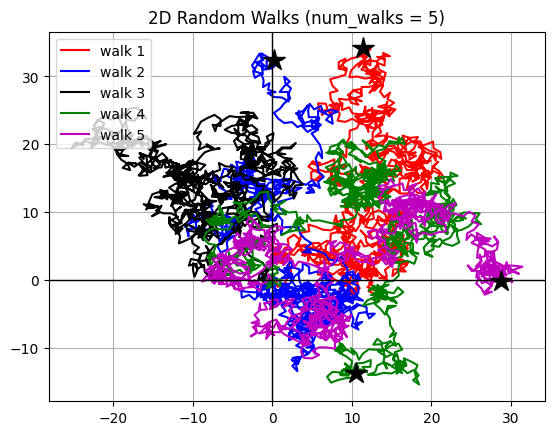

In [ ]:
#
#  Simple in-line (no module) python random walk program in 2D.
#  Performs and plots up to 5 random walks.
#  Walkers start at the origin: (x,y) = (0,0)
#  At each step, walker moves only one unit in random direction
#

import sys
import random as random
import numpy as np
import matplotlib.pyplot as plt
random.seed(None)        # Seed generator, None => system clock

def rand_grid():
    xdelta, ydelta = random.choice( [(1,0),(0,1),(-1,0),(0,-1)] )
    return xdelta, ydelta

def rand_angle():
    """
    Performs unit 2D random step at random angle ( 0 to 2*PI)
    Returns (x,y) co-ordinates of unit step at random angle
     """
    rand_angle = random.uniform(0,2.*np.pi)
    xdelta = np.sin(rand_angle)
    ydelta = np.cos(rand_angle)
    return xdelta, ydelta

def random_walk2d(steps):
    """
    Performs 2D random walk with number of steps = steps
    Returns (x,y) co-ordinates of unit step at random angle
    """
    xwalk = np.zeros(steps+1)
    ywalk = np.zeros(steps+1)
    x, y  = 0, 0
    for i in range(steps):
        xdelta, ydelta = rand_angle()
        x += xdelta
        y += ydelta
        xwalk[i+1] = x
        ywalk[i+1] = y
    return xwalk, ywalk


#
#   Enter number of walks to plot and check entered value
#


num_walks = int(input('Enter number of walks to do (1-5):'))
if num_walks <= 0 or num_walks >5:
    print (f'Number of walks selected = {num_walks} must be between 1 and 5')
    sys.exit(0)


#  Sets number of steps in each random walk
num_steps = 1000
line_type = ['r-','b-','k-','g-','m-']
plt.clf     #  Clear the graph figure


#  Perform random walks and plot result for each walk
for i in range(num_walks):
    xwalk1, ywalk1 = random_walk2d(num_steps)
    plt.plot(xwalk1, ywalk1, line_type[i], label = f'walk {i+1}')
    plt.plot(xwalk1[-1],ywalk1[-1], 'k*', ms=16)  # Put large * to mark end of walk

#  Create bold lines on each axis through origin
plt.axhline(0, color='black', lw=1)  # Creates a horizontal black line on x-axis
plt.axvline(0, color='black', lw=1)  # Creates a vertical black line on y-axis

#  Set plot title , legend, and grid
plt.title(f'2D Random Walks (num_walks = {num_walks})')
plt.legend(loc="upper left")
plt.grid(True)
#plt.savefig("rw2d_simple1.png")
plt.show()

# 2D Random Walk Statistics


**Now we can run experiments!!**



One key question we might have is how far a random walker gets from the starting point for  given number of
"time-steps". In other words, how much "territory" will a randomly moving molecule inside a cell explore?


>  1. A prediction from **diffusion theory** is that a random walker will be (on average) $\sqrt{N}$ away from starting point after $N$ time-steps of one unit each. For example, if we run a random walk with 100 steps, we would expect the walker to be $\sqrt{100}$ or 10 units away from starting point on average. THIS IS INDEPENDENT OF THE NUMBER OF SPATIAL DIMENSIONS!
>  2. We can also calculate the diffusion constant D, defined by the relation <r^2> = D*N, where N is the number of steps taken and <r^2> denotes the average of the square of the position r after N steps.


Devise an experiment to test this assumption with the program, run the experiment, and plot your result (manually). For example, you may want to vary the number of steps from 100 to 1000 by 100, and plot the average squre distance (i.e. <r^2>) versus number of steps. Note: Keep number of simulations to 1000 or less for each run, to keep the runtime down.

You can (and should!) also try to determine the diffusion constant D for different types of random walks (1D, 2D grid, 2D angle, different types of steps, etc.) and compare them with each other.

In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt

def rand_grid():
    xdelta, ydelta = random.choice( [(1,0),(0,1),(-1,0),(0,-1)] )
    return xdelta, ydelta

def rand_grid_alt():
    xdelta = random.choice( [-1, 0, 1] )
    ydelta = random.choice( [-1, 0, 1] )
    return xdelta, ydelta

def rand_angle():
    """
    Performs unit 2D random step at random angle ( 0 to 2*PI)
    Returns (x,y) co-ordinates of unit step at random angle
    """
    rand_angle = random.uniform(0,2.*np.pi)
    xdelta = np.sin(rand_angle)
    ydelta = np.cos(rand_angle)
    return xdelta, ydelta

def random_walk2d_angle(steps):
    """
    Performs 2D random walk with number of steps = steps
    Returns (x,y) co-ordinates of unit step at random angle
    """

    xwalk = np.zeros(steps+1)
    ywalk = np.zeros(steps+1)
    x, y  = 0, 0
    for i in range(steps):
        xdelta, ydelta = rand_angle()
        x += xdelta
        y += ydelta
        xwalk[i+1] = x
        ywalk[i+1] = y
    return xwalk, ywalk

def random_walk2d_grid(steps):
    """
    Performs 2D random walk with number of steps = steps
    Returns (x,y) co-ordinates of unit step at random grid
    """

    xwalk = np.zeros(steps+1)
    ywalk = np.zeros(steps+1)
    x, y  = 0, 0
    for i in range(steps):
        xdelta, ydelta = rand_grid()
        x += xdelta
        y += ydelta
        xwalk[i+1] = x
        ywalk[i+1] = y
    return xwalk, ywalk

def random_walk2d_grid_alt(steps):
    """
    Performs 2D random walk with number of steps = steps
    Returns (x,y) co-ordinates of unit step at random grid type 2
    """

    xwalk = np.zeros(steps+1)
    ywalk = np.zeros(steps+1)
    x, y  = 0, 0
    for i in range(steps):
        xdelta, ydelta = rand_grid_alt()
        x += xdelta
        y += ydelta
        xwalk[i+1] = x
        ywalk[i+1] = y
    return xwalk, ywalk

def random_walk_1d(steps):
    """  Performs 1D random walk with number steps = steps """
    walk = np.zeros(steps+1)
    for i in range(steps):
        walk[i+1] = walk[i] + random.choice([-1,1])
    return walk

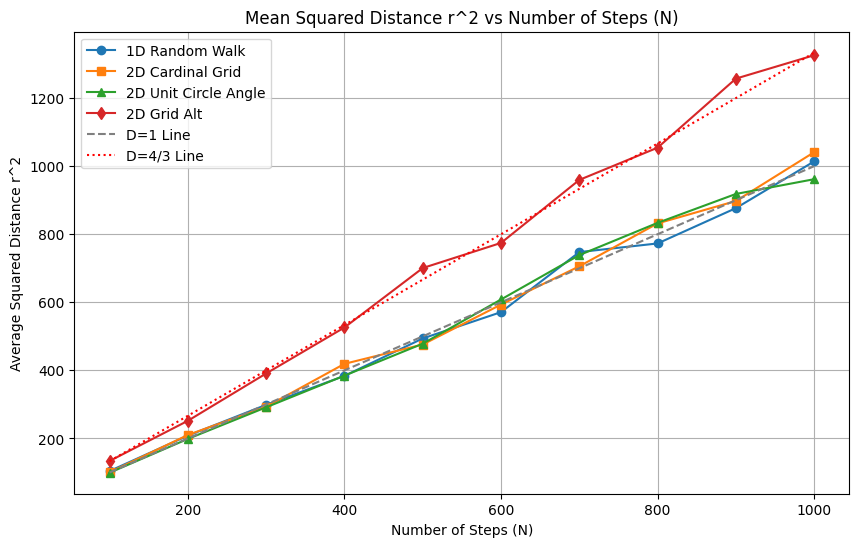

1D Walk: 1.014
2D Cardinal Grid: 1.041
2D Unit Circle Angle: 0.962
2D Grid Alt: 1.326


In [7]:
def experiment(walk_func, steps_range, simulations=1000):
    """
    Runs multiple simulations for different step values and returns average squared distances.
    """
    avg_distances = []

    for steps in steps_range:
        distance = 0
        for _ in range(simulations):
            if walk_func.__name__ == 'random_walk_1d':
                walk_result = walk_func(steps)
                final_r2 = walk_result[-1]**2
            else:
                xwalk, ywalk = walk_func(steps)
                final_r2 = xwalk[-1]**2 + ywalk[-1]**2

            distance += final_r2

        avg_distances.append(distance / simulations)

    return np.array(avg_distances)


steps_range = range(100, 1100, 100)
simulations = 1000

position_1d = experiment(random_walk_1d, steps_range, simulations)
position_grid = experiment(random_walk2d_grid, steps_range, simulations)
position_angle = experiment(random_walk2d_angle, steps_range, simulations)
position_grid_alt = experiment(random_walk2d_grid_alt, steps_range, simulations)

plt.figure(figsize=(10, 6))
plt.plot(steps_range, position_1d, 'o-', label='1D Random Walk')
plt.plot(steps_range, position_grid, 's-', label='2D Cardinal Grid')
plt.plot(steps_range, position_angle, '^-', label='2D Unit Circle Angle')
plt.plot(steps_range, position_grid_alt, 'd-', label='2D Grid Alt')

plt.plot(steps_range, steps_range, '--', color='gray', label='D=1 Line')
plt.plot(steps_range, (4/3)*np.array(steps_range), ':', color='red', label='D=4/3 Line')

plt.title(rf'Mean Squared Distance r^2 vs Number of Steps (N)')
plt.xlabel('Number of Steps (N)')
plt.ylabel(rf'Average Squared Distance r^2')
plt.legend()
plt.grid(True)
plt.show()

print(f"1D Walk: {position_1d[-1] / 1000:.3f}")
print(f"2D Cardinal Grid: {position_grid[-1] / 1000:.3f}")
print(f"2D Unit Circle Angle: {position_angle[-1] / 1000:.3f}")
print(f"2D Grid Alt: {position_grid_alt[-1] / 1000:.3f}")